In [1]:
from utils import get_param_dict, plot_trajectories_all_models

In [3]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
import os
from utils import *
from tqdm import tqdm
from pprint import pprint

from models import DistanceCellModel, VectorCellModel, NestedModel
from simulation import run_load_simulation
OUTPUT_DIR = 'simulation_outputs'
# ================= MODEL & SIMULATION PARAMETERS =================
N_SIM_ROUND = 5
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']

no_distortion_params = {'undistorted-0': {'distortion': 'none-global', 'a': None, 'b':None}}
example_distortion_params = {'undistorted-0': {'distortion': 'none-global', 'a': None, 'b':None},
                     'shear1': {'distortion': 'shear', 'a': 0, 'b': 0.3},
                     'stretch1': {'distortion': 'stretch', 'a': 1, 'b': 0.67}}

# Global distortion parameters
shear_drift_global_params = get_param_dict({'a': [0], 'b': [0, 0.3, 0.6, 1, 2, 5], 'b_drift': [0.1]}, 
                                     'shear+drift-global', incl_undistorted=False)

shear_global_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                     'shear-global', incl_undistorted=False)
stretch_global_params = get_param_dict({'a': [2], 'b': [1, 0.7, 0.5, 0.3]}, 
                                       'stretch-global', incl_undistorted=False)

# Local distortion parameters
shear_local_params = get_param_dict({'a': [0], 'b': [0, 0.05, 0.1, 0.5]}, 
                                     'shear-local', incl_undistorted=False)
stretch_local_params = get_param_dict({'a': [1], 'b': [1, 0.99, 0.95, 0.9]}, 
                                       'stretch-local', incl_undistorted=False)

# Modular distortion parameters
shear_modular_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                'shear-modular', incl_undistorted=False)
# =================================================================


In [4]:
shear_global_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5]}, 
                                     'shear-global', incl_undistorted=False)
for curr_distortion_params in [shear_global_params]: #, shear_modular_params, shear_local_params]:
    plot_trajectories_all_models(distortion_params=curr_distortion_params, 
                                model_names=model_names,
                                n_trials=N_TRIALS,
                                hexagonal_projection=False,
                                n_sim_round=N_SIM_ROUND,
                                save_fig=False)
    

TypeError: plot_trajectories_all_models() missing 3 required positional arguments: 'arena_width', 'step_size', and 'convergence_threshold'

In [6]:
for curr_distortion_params in [shear_global_params, shear_modular_params, shear_local_params]:
    for distortion_name in curr_distortion_params.keys():
        print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
        for model_name in model_names:
            x_histories, y_histories = run_load_simulation(model_name, 
                                                        arena_width=ARENA_WIDTH, 
                                                        step_size=STEP_SIZE,
                                                        convergence_threshold=CONV_THRESH,
                                                        n_trials=N_TRIALS, 
                                                        distortion_params=curr_distortion_params[distortion_name],
                                                        hexagonal_projection=HEX_PROJ,
                                                        n_sim_round=N_SIM_ROUND,
                                                        save_data=True)
      #  plot_trajectories(model_name, x_histories, y_histories, arena_width=ARENA_WIDTH, hexagonal_projection=HEX_PROJ)
      #  plot_error(x_histories, y_histories) i left it her3e lol


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
[961.08, 640.72, 427.15, 284.77, 189.84, 126.56, 84.38, 56.25, 37.5, 25.0]
Running new simulation for Nested Model with distortion=shear-global (a=0, b=0)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


Simulating trials: 100%|██████████| 100/100 [00:26<00:00,  3.74it/s]


Saved simulation data to simulation_outputs/round-5/global/nm_trials-100_shear-global_a-0_b-0.pkl
[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
Running new simulation for Distance Cell Model with distortion=shear-global (a=0, b=0)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


Simulating trials: 100%|██████████| 100/100 [00:11<00:00,  8.57it/s]


Saved simulation data to simulation_outputs/round-5/global/dcm_trials-100_shear-global_a-0_b-0.pkl
[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
Running new simulation for Vector Cell Model with distortion=shear-global (a=0, b=0)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


...

Saved simulation data to simulation_outputs/round-5/global/nm_trials-100_shear-global_a-0_b-1.pkl
[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
Running new simulation for Distance Cell Model with distortion=shear-global (a=0, b=1)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


Simulating trials: 100%|██████████| 100/100 [00:14<00:00,  6.89it/s]


Saved simulation data to simulation_outputs/round-5/global/dcm_trials-100_shear-global_a-0_b-1.pkl
[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
Running new simulation for Vector Cell Model with distortion=shear-global (a=0, b=1)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


Simulating trials:  28%|██▊       | 28/100 [01:26<03:42,  3.09s/it]


KeyboardInterrupt: 

In [ ]:
selected_distortion_params = shear_modular_params
for distortion_name in selected_distortion_params.keys():
    print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
    for model_name in model_names:
        x_histories, y_histories = run_load_simulation(model_name, 
                                                    arena_width=ARENA_WIDTH, 
                                                    step_size=STEP_SIZE,
                                                    convergence_threshold=CONV_THRESH,
                                                    n_trials=N_TRIALS, 
                                                    distortion_params=selected_distortion_params[distortion_name],
                                                    hexagonal_projection=HEX_PROJ,
                                                    save_plot=True    )


 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear-modular-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
[961.08, 640.72, 427.15, 284.77, 189.84, 126.56, 84.38, 56.25, 37.5, 25.0]
Running new simulation for Nested Model with distortion=shear-modular (a=0, b=0)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


Simulating trials: 100%|██████████| 81/81 [00:25<00:00,  3.13it/s]


Saved simulation data to simulation_outputs/modular/nm_trials-81_shear-modular_a-0_b-0.pkl
[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
Running new simulation for Distance Cell Model with distortion=shear-modular (a=0, b=0)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


Simulating trials: 100%|██████████| 81/81 [00:11<00:00,  6.95it/s]


Saved simulation data to simulation_outputs/modular/dcm_trials-81_shear-modular_a-0_b-0.pkl
[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
Running new simulation for Vector Cell Model with distortion=shear-modular (a=0, b=0)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


...

Saved simulation data to simulation_outputs/modular/nm_trials-81_shear-modular_a-0_b-10.pkl
[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
Running new simulation for Distance Cell Model with distortion=shear-modular (a=0, b=10)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


Simulating trials: 100%|██████████| 81/81 [00:04<00:00, 17.30it/s]


Saved simulation data to simulation_outputs/modular/dcm_trials-81_shear-modular_a-0_b-10.pkl
[25.0, 37.5, 56.25, 84.38, 126.56, 189.84, 284.77, 427.15, 640.72, 961.08]
Running new simulation for Vector Cell Model with distortion=shear-modular (a=0, b=10)...
PARAMS: M=10, min_scale=25, scale_ratio=1.5, m=20, r_max=30, poiss_time_w=0.1
hexagonal_projection: True
Projecting evenly spaced start locations onto hexagonal grid axes...


Simulating trials: 100%|██████████| 81/81 [03:03<00:00,  2.27s/it]

Saved simulation data to simulation_outputs/modular/vcm_trials-81_shear-modular_a-0_b-10.pkl



 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear+drift-global-1 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Loading simulation data from simulation_outputs/global/nm_trials-55_shear+drift-global_a-0_b-0_bdrift-0.1.pkl


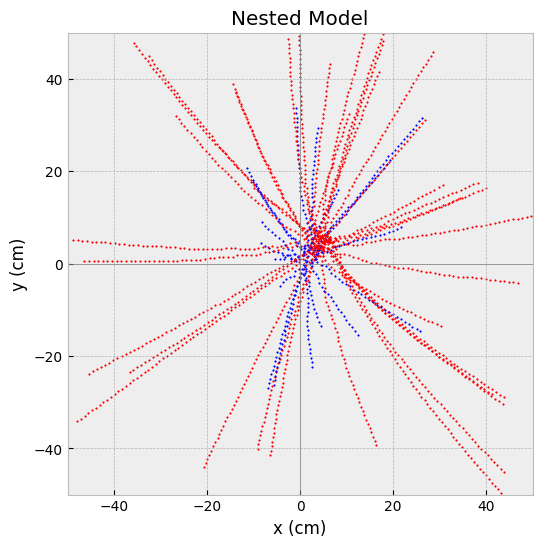

Successful trials: 19/55 (34.5%)
Mean error: 5.71, Median error: 5.90, Std error: 2.19
Loading simulation data from simulation_outputs/global/dcm_trials-55_shear+drift-global_a-0_b-0_bdrift-0.1.pkl


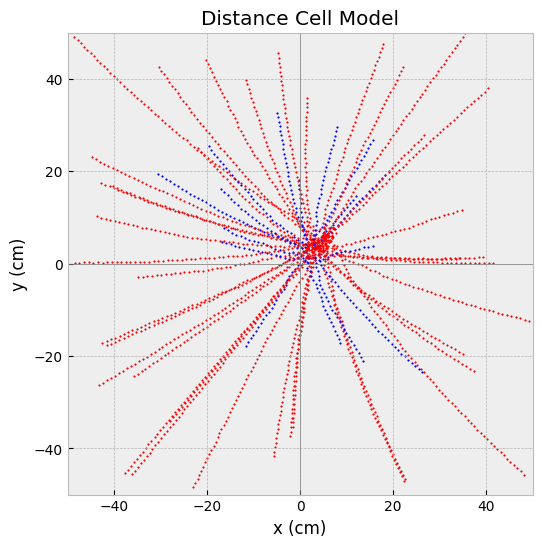

Successful trials: 16/55 (29.1%)
Mean error: 5.94, Median error: 5.56, Std error: 2.03
Loading simulation data from simulation_outputs/global/vcm_trials-55_shear+drift-global_a-0_b-0_bdrift-0.1.pkl


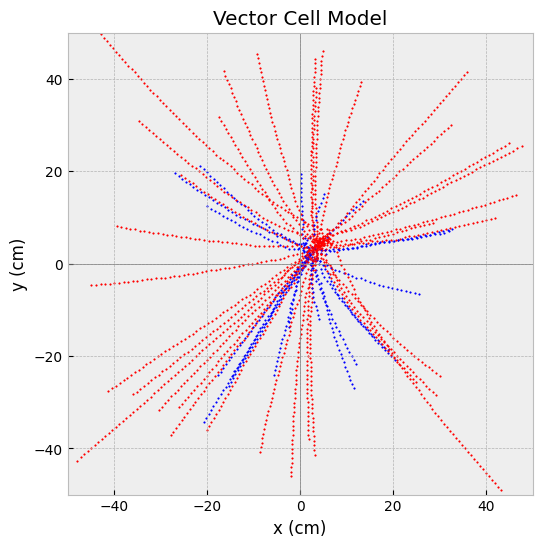

Successful trials: 21/55 (38.2%)
Mean error: 5.46, Median error: 5.90, Std error: 1.76

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear+drift-global-2 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Loading simulation data from simulation_outputs/global/nm_trials-55_shear+drift-global_a-0_b-0.3_bdrift-0.1.pkl


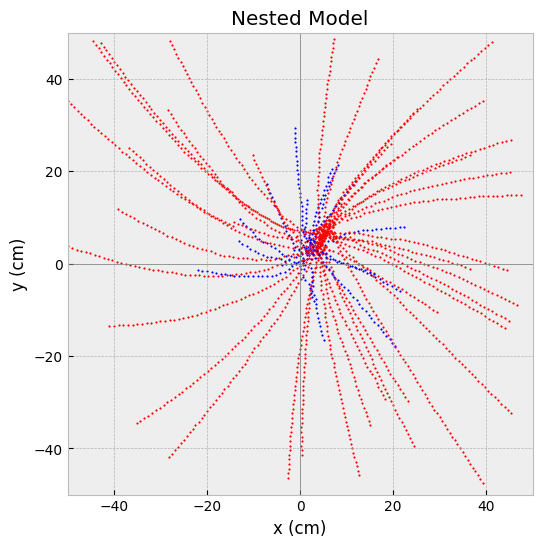

Successful trials: 17/55 (30.9%)
Mean error: 6.60, Median error: 6.80, Std error: 2.79
Loading simulation data from simulation_outputs/global/dcm_trials-55_shear+drift-global_a-0_b-0.3_bdrift-0.1.pkl


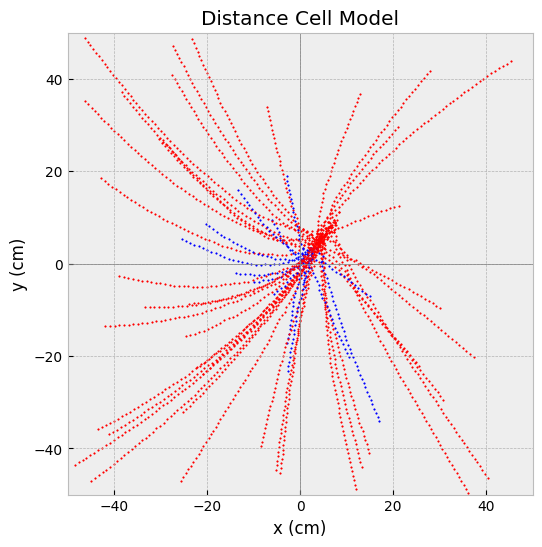

Successful trials: 15/55 (27.3%)
Mean error: 6.68, Median error: 6.87, Std error: 3.03
Loading simulation data from simulation_outputs/global/vcm_trials-55_shear+drift-global_a-0_b-0.3_bdrift-0.1.pkl


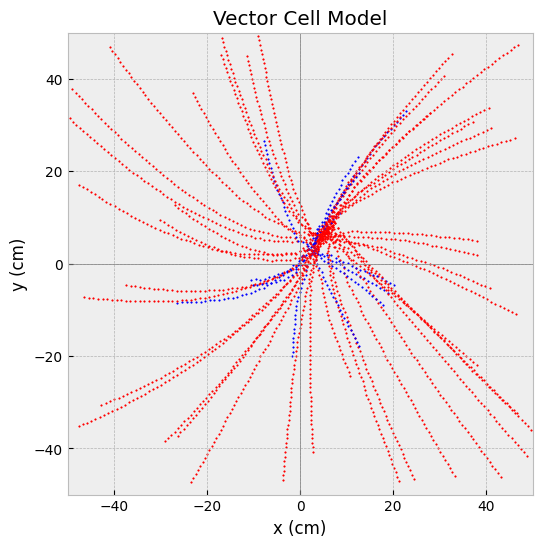

Successful trials: 13/55 (23.6%)
Mean error: 7.20, Median error: 7.44, Std error: 2.71

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear+drift-global-3 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Loading simulation data from simulation_outputs/global/nm_trials-55_shear+drift-global_a-0_b-0.6_bdrift-0.1.pkl


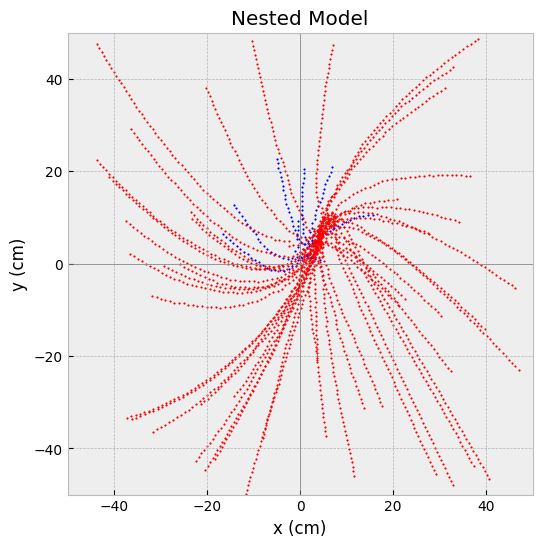

Successful trials: 8/55 (14.5%)
Mean error: 7.98, Median error: 8.05, Std error: 2.89
Loading simulation data from simulation_outputs/global/dcm_trials-55_shear+drift-global_a-0_b-0.6_bdrift-0.1.pkl


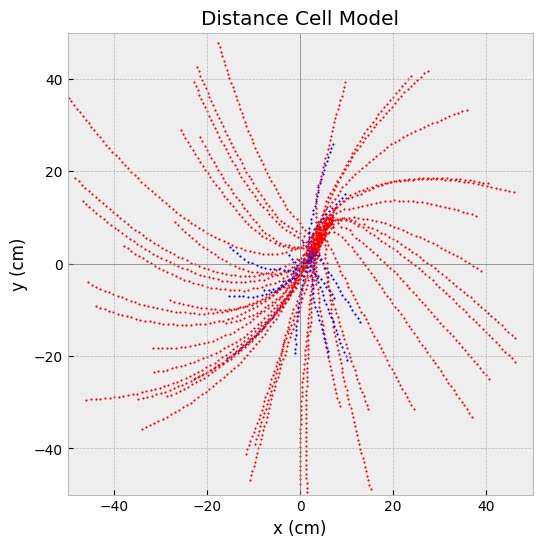

Successful trials: 13/55 (23.6%)
Mean error: 7.52, Median error: 7.68, Std error: 2.96
Loading simulation data from simulation_outputs/global/vcm_trials-55_shear+drift-global_a-0_b-0.6_bdrift-0.1.pkl


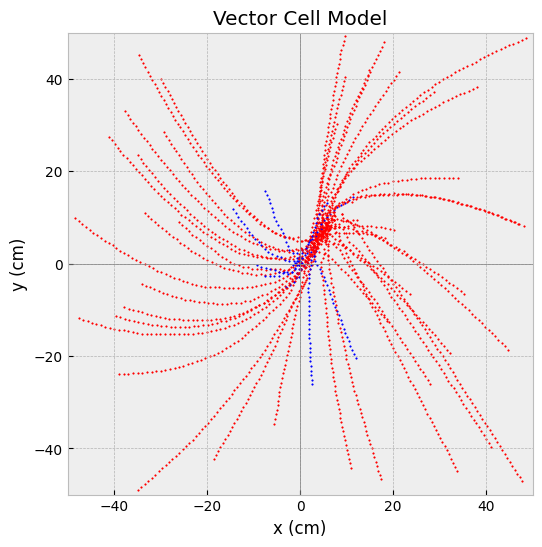

Successful trials: 12/55 (21.8%)
Mean error: 7.51, Median error: 7.88, Std error: 3.45

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear+drift-global-4 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Loading simulation data from simulation_outputs/global/nm_trials-55_shear+drift-global_a-0_b-1_bdrift-0.1.pkl


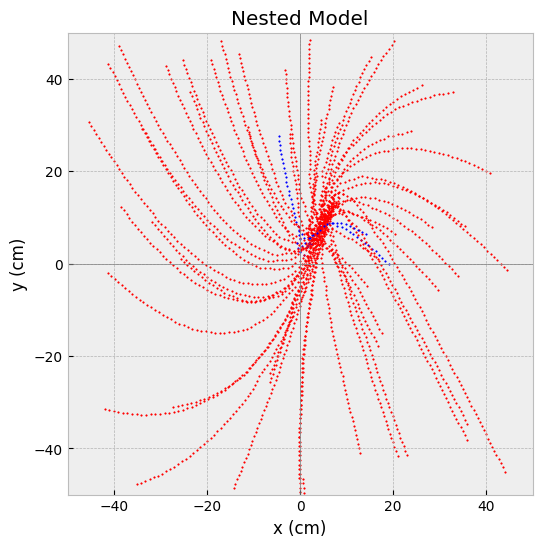

Successful trials: 4/55 (7.3%)
Mean error: 10.01, Median error: 9.91, Std error: 3.70
Loading simulation data from simulation_outputs/global/dcm_trials-55_shear+drift-global_a-0_b-1_bdrift-0.1.pkl


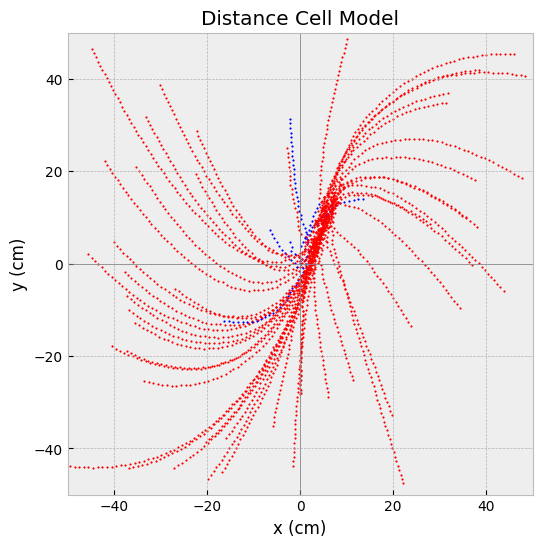

Successful trials: 6/55 (10.9%)
Mean error: 10.69, Median error: 11.21, Std error: 4.27
Loading simulation data from simulation_outputs/global/vcm_trials-55_shear+drift-global_a-0_b-1_bdrift-0.1.pkl


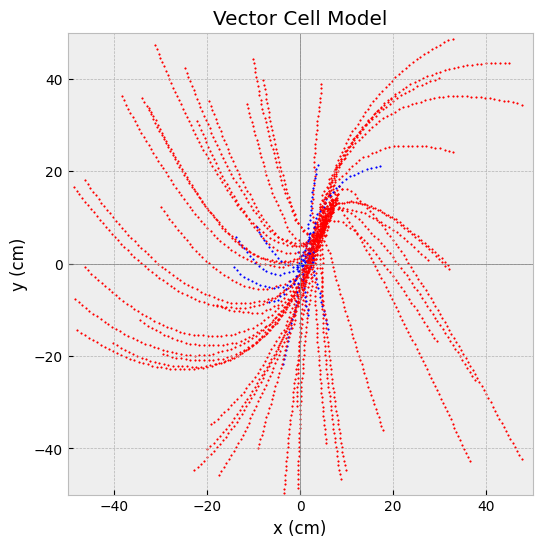

Successful trials: 9/55 (16.4%)
Mean error: 10.57, Median error: 10.97, Std error: 4.29

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear+drift-global-5 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Loading simulation data from simulation_outputs/global/nm_trials-55_shear+drift-global_a-0_b-2_bdrift-0.1.pkl


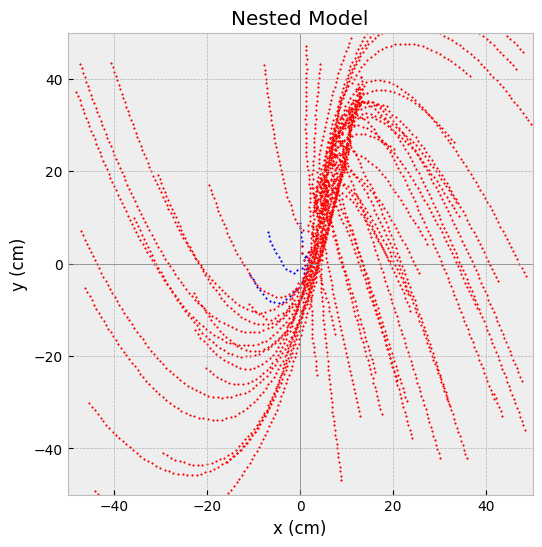

Successful trials: 3/55 (5.5%)
Mean error: 19.83, Median error: 17.35, Std error: 9.85
Loading simulation data from simulation_outputs/global/dcm_trials-55_shear+drift-global_a-0_b-2_bdrift-0.1.pkl


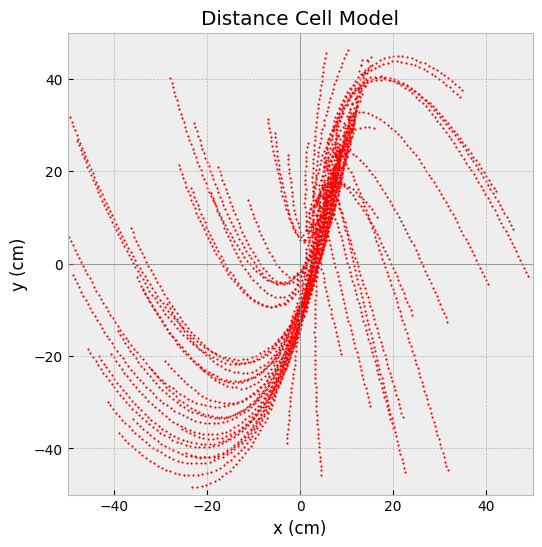

Successful trials: 0/55 (0.0%)
Mean error: 21.58, Median error: 21.15, Std error: 9.91
Loading simulation data from simulation_outputs/global/vcm_trials-55_shear+drift-global_a-0_b-2_bdrift-0.1.pkl


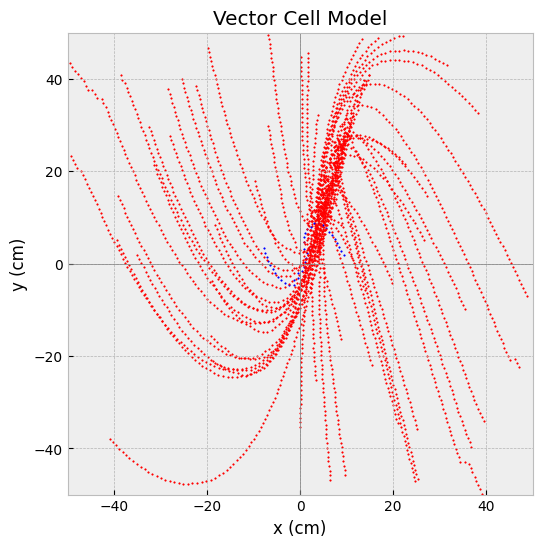

Successful trials: 2/55 (3.6%)
Mean error: 19.09, Median error: 18.45, Std error: 9.07

 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+ RUNNING SIMULATIONS FOR DISTORTION=shear+drift-global-6 -+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+-+
Loading simulation data from simulation_outputs/global/nm_trials-55_shear+drift-global_a-0_b-5_bdrift-0.1.pkl


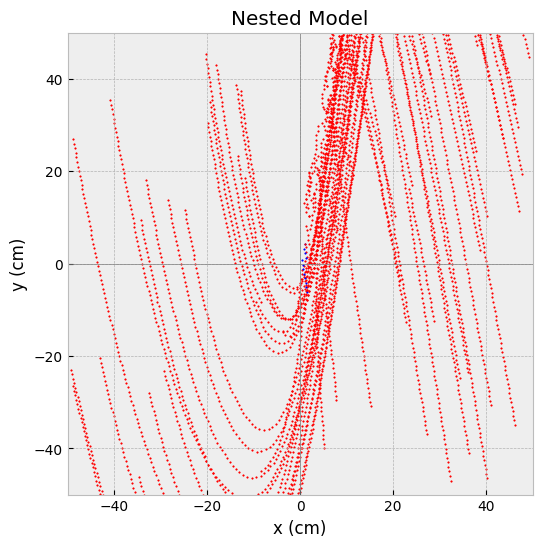

Successful trials: 1/55 (1.8%)
Mean error: 96.65, Median error: 75.77, Std error: 66.60
Loading simulation data from simulation_outputs/global/dcm_trials-55_shear+drift-global_a-0_b-5_bdrift-0.1.pkl


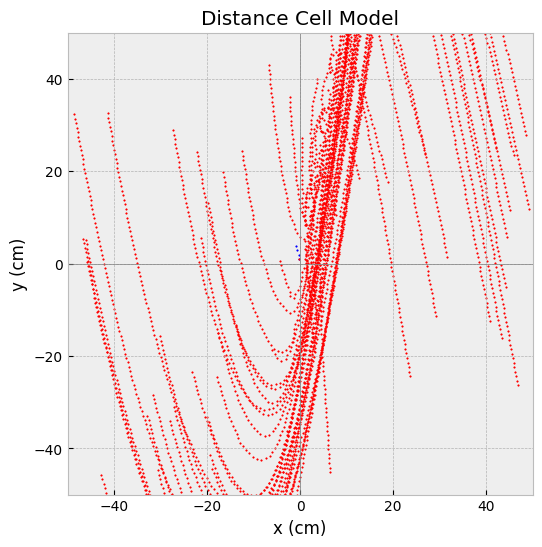

Successful trials: 1/55 (1.8%)
Mean error: 96.84, Median error: 78.59, Std error: 74.86
Loading simulation data from simulation_outputs/global/vcm_trials-55_shear+drift-global_a-0_b-5_bdrift-0.1.pkl


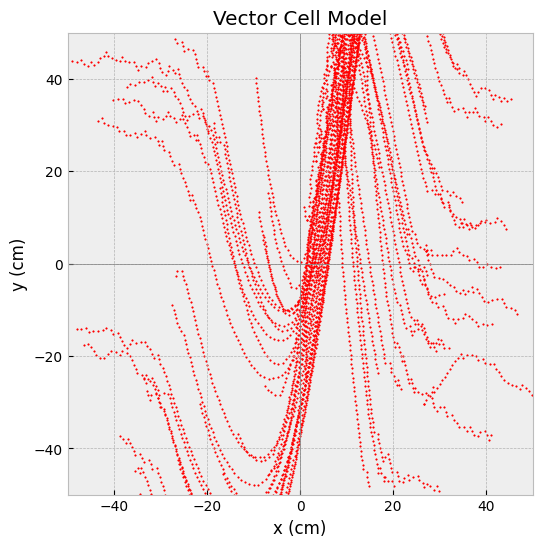

Successful trials: 0/55 (0.0%)
Mean error: 87.55, Median error: 60.32, Std error: 55.46


In [ ]:
selected_distortion_params = shear_drift_global_params
for distortion_name in selected_distortion_params.keys():
    print(F'\n {"-+" * 30} RUNNING SIMULATIONS FOR DISTORTION={distortion_name} {"-+" * 30}')
    for model_name in model_names:
        x_histories, y_histories = run_load_simulation(model_name, 
                                                    arena_width=ARENA_WIDTH, 
                                                    step_size=STEP_SIZE,
                                                    convergence_threshold=CONV_THRESH,
                                                    n_trials=N_TRIALS, 
                                                    distortion_params=selected_distortion_params[distortion_name],
                                                    hexagonal_projection=HEX_PROJ
                                                        )
        plot_trajectories(model_name, x_histories, y_histories, hexagonal_projection=HEX_PROJ)
        plot_error(x_histories, y_histories)


In [ ]:
M = 10
b_max = 0.5
scale_ratio = 3/2
modular_bs = []
for i in np.arange(M, 0, -1):
    modular_bs.append(round(b_max / (scale_ratio ** (M-i)),2))
modular_bs = np.array(modular_bs)[::-1]
modular_bs

array([0.01, 0.02, 0.03, 0.04, 0.07, 0.1 , 0.15, 0.22, 0.33, 0.5 ])

In [ ]:
for trial in range(len(x_histories)):

    xs = x_histories[trial]
    ys = y_histories[trial]
    pos_xy_mat = np.array([xs, ys])
 #   xs = project_onto_axis(pos_xy_mat, 1)
 #   ys = project_onto_axis(pos_xy_mat, 2)
    end_x = xs[-1]
    end_y = ys[-1]
    if end_x > 3:
        print(f'trial {trial}: ------end_x:',end_x)
        for i in range(len(xs)):
            if i < 1:
                continue
            end_x = xs[i]
            end_y = ys[i]
            old_x = xs[i-1]
            old_y = ys[i-1]
            distance_moved = np.sqrt((end_x - old_x) ** 2 + (end_y - old_y) ** 2)
            print(f'{i}: at ({end_x},{end_y}), distance_moved:', distance_moved)


trial 0: ------end_x: 33.115975252485214
1: at (-47.0158288647881,-14.115632388423826), distance_moved: 0.9999999999979925
2: at (-46.02104851802823,-14.013592877958839), distance_moved: 0.9999999999978082
3: at (-45.415822124023485,-14.809646275663678), distance_moved: 0.9999999999987025
4: at (-44.457108165905076,-14.525274078526282), distance_moved: 0.9999999999979081
5: at (-43.45711148805175,-14.522696428885256), distance_moved: 0.9999999999976791
6: at (-42.46255081827849,-14.418537539991124), distance_moved: 0.999999999997752
7: at (-41.63281075356695,-13.860387537743883), distance_moved: 0.9999999999980506
8: at (-40.76130082793939,-14.350765401771875), distance_moved: 0.9999999999980089
9: at (-40.14297955790945,-15.136690847997894), distance_moved: 0.9999999999985009
10: at (-39.15759056021642,-14.966371961139732), distance_moved: 0.9999999999975379
11: at (-38.77985119404951,-15.892283928470297), distance_moved: 0.999999999999067
12: at (-38.3940577821617,-16.81486912417967)

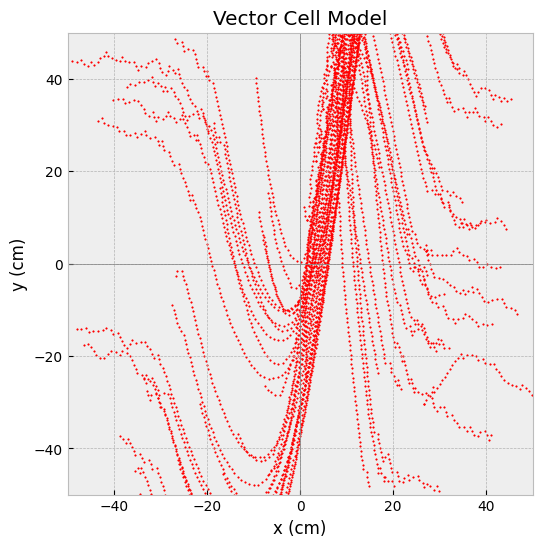

Successful trials: 0/55 (0.0%)


In [ ]:
def plot_trajectories(model_name, x_histories, y_histories, arena_width = 50, hexagonal_projection=True):
    long_names = {'nm': 'Nested Model', 'dcm': 'Distance Cell Model', 'vcm': 'Vector Cell Model'}

    n_trials = len(x_histories)
    plt.figure(figsize=(6, 6))

    # Project the trajectories onto the hexagonal axes
    if hexagonal_projection:
        x_histories_proj = []
        y_histories_proj = []
        for trial in range(len(x_histories)):
            pos_xy_mat = np.array([x_histories[trial], y_histories[trial]])
            proj_X = project_onto_axis(pos_xy_mat, 1)
            proj_Y = project_onto_axis(pos_xy_mat, 2)
            x_histories_proj.append(proj_X)
            y_histories_proj.append(proj_Y)
        x_histories = x_histories_proj
        y_histories = y_histories_proj

    success_count = 0
    for trial in range(n_trials):
        last_x = x_histories[trial][-1]
        last_y = y_histories[trial][-1]
        success = np.sqrt(last_x**2 + last_y**2) <= 5
        color = 'blue' if success else 'red'
        success_count += success
        plt.scatter(x_histories[trial], y_histories[trial], color=color, s=1)
        plt.scatter(x_histories[trial][-1], y_histories[trial][-1], color='red', s=1)
        
    plt.xlim(-arena_width, arena_width)
    plt.ylim(-arena_width, arena_width)
  #plt.xticks([])
  #  plt.yticks([])
 #   plt.xlim(-5,5)
 #   plt.ylim(-5,5)
    plt.title(f'{long_names[model_name]}')
    plt.xlabel('x (cm)')
    plt.ylabel('y (cm)')
    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)

    plt.show()
    print(f'Successful trials: {success_count}/{n_trials} ({(success_count/n_trials)*100:.1f}%)')
plot_trajectories(model_name, x_histories, y_histories, hexagonal_projection=False)

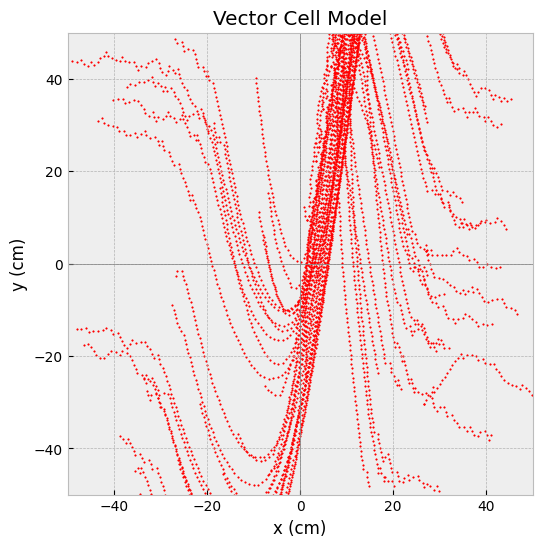

Successful trials: 0/55 (0.0%)


In [ ]:
plot_trajectories(model_name, x_histories, y_histories, hexagonal_projection=False)

### Translation vector simulation

In [1]:
def translation_vec_simulation(model_name, N=1000, arena_width = 50, gc_distortion=None, plot_results=True):

    #Initialize corresponding model
    if model_name == 'dcm':
        model = DistanceCellModel(arena_width=arena_width, dc_res = 0.04)
        title = 'DistanceCellModel'
    elif model_name == 'vcm':
        model = VectorCellModel(arena_width=arena_width)
        title = 'VectorCellModel'
    elif model_name == 'nm':
        model = NestedModel(arena_width=arena_width)
        title = 'NestedModel'
    else:
        raise ValueError("Invalid model name")

    # Generate random starting positions and target positions
    a_s = [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
    b_s = [np.zeros(N) for _ in range(2)]  # Target positions are all zeros [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
  #  b_s = [(np.random.rand(N) * arena_width * 2) - arena_width for _ in range(2)]
    # Apply distortion if provided
    if gc_distortion is None or gc_distortion.distortion is None:
        print('No distortion applied.')
        a_s_dist = a_s
        b_s_dist = b_s
    else: 
        print(f'Applying {gc_distortion.distortion} distortion with a={gc_distortion.a}, b={gc_distortion.b}')
        a_s_dist = gc_distortion.apply(a_s[0], a_s[1])
        b_s_dist = gc_distortion.apply(b_s[0], b_s[1])

    # Generate translation vectors and decode them using the model
    true_trans_vecs = np.array([(b_s[0] - a_s[0]), (b_s[1] - a_s[1])])
    pred_trans_vecs = []
    for i in range(N):
        
        curr_pop_vec = model.forward(a=[a_s_dist[0][i], a_s_dist[1][i]], b=[b_s_dist[0][i], b_s_dist[1][i]])
        pred_trans_vecs.append(curr_pop_vec)
    #    print(f'b_s[0][{i}]:', b_s[0][i])
    #    true_distance = [b_s[0][i] - a_s[0][i], b_s[1][i] - a_s[1][i] ]
    #    print(f'For trial {i+1}/{N}, true distance: ({true_distance[0]}, {true_distance[1]}), decoded b_hat: ({curr_pop_vec[0]}, {curr_pop_vec[1]})')
    pred_trans_vecs = np.array(pred_trans_vecs).T




    # Plot two plots for x and y
    if plot_results:
        plt.subplots(1, 2, figsize=(12, 5))
        for i in range(2):
            plt.subplot(1, 2, i+1)
            plt.scatter(true_trans_vecs[i] / 100, pred_trans_vecs[i] / 100, color='black', s=1)
            plt.xlabel('True Translation Vector (m)')
            plt.ylabel('Decoded Translation Vector (m)')
            curr_axis = 'x' if i == 0 else 'y'
            plt.title(f'{curr_axis}-axis')
        plt.suptitle(title)
        plt.show()

    return a_s, b_s, pred_trans_vecs

In [ ]:


def plot_trans_vec_results(trans_vec_results, arena_width=50):
    model_names = trans_vec_results.keys()
    for model_name in model_names:
        a_s = trans_vec_results[model_name][0]
        b_s = trans_vec_results[model_name][1]
        pred_trans_vecs = trans_vec_results[model_name][2]
        plt.figure(figsize=(8, 8))
        plt.plot(a_s[0], a_s[1], 'o', color='black', label='Start Position', markersize=1)
        plt.plot(b_s[0], b_s[1], 'o', label='End Position', markersize=1)
        for i in range(pred_trans_vecs.shape[1]):
            plt.arrow(a_s[0][i], a_s[1][i], pred_trans_vecs[0][i], pred_trans_vecs[1][i], head_width=1, head_length=1, fc='red', ec='black', alpha=0.5)
        plt.xlabel('x-axis (m)')
        plt.ylabel('y-axis (m)')
        plt.xlim(-arena_width, arena_width)
        plt.ylim(-arena_width, arena_width)
        plt.title('Translation Vectors for Distance Cell Model')
        plt.show()
plot_trans_vec_results(trans_vec_results)

NameError: name 'trans_vec_results' is not defined

Applying shear distortion with a=0.3, b=0.3


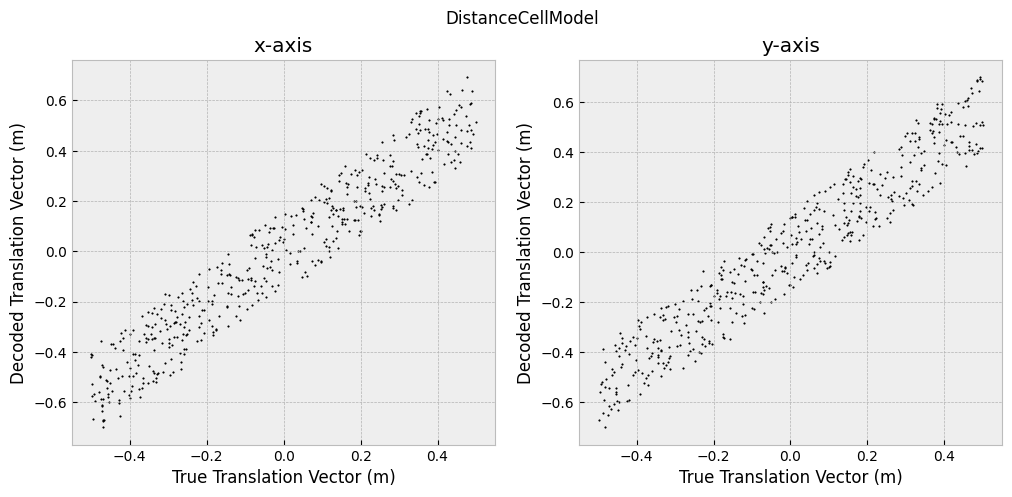

Applying shear distortion with a=0.3, b=0.3


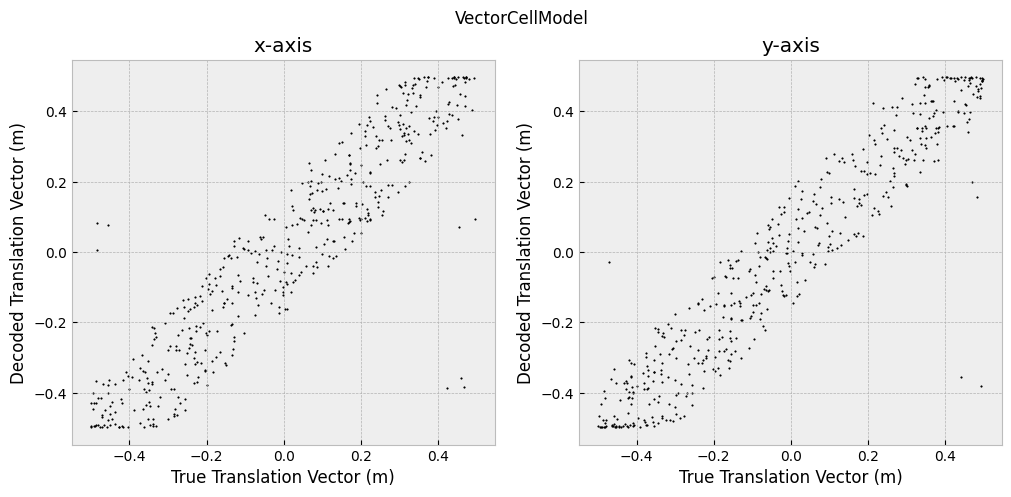

Applying shear distortion with a=0.3, b=0.3


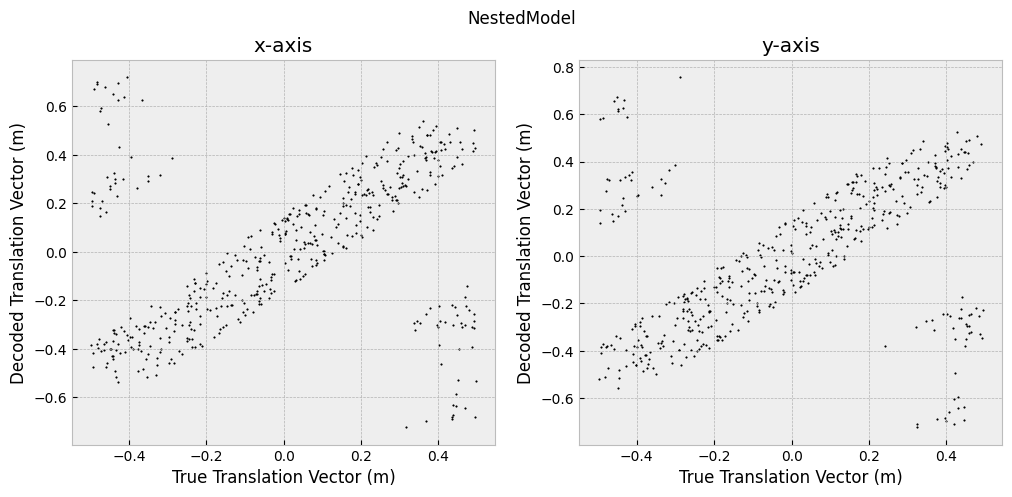

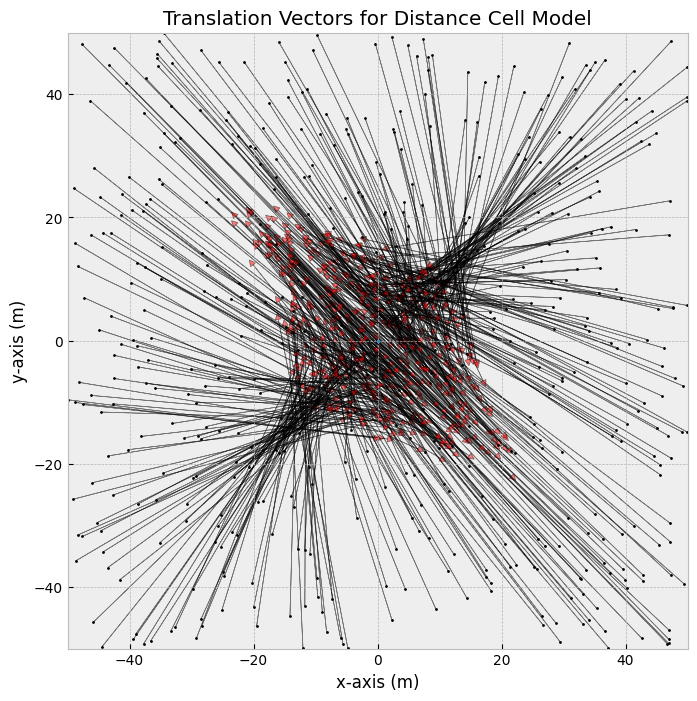

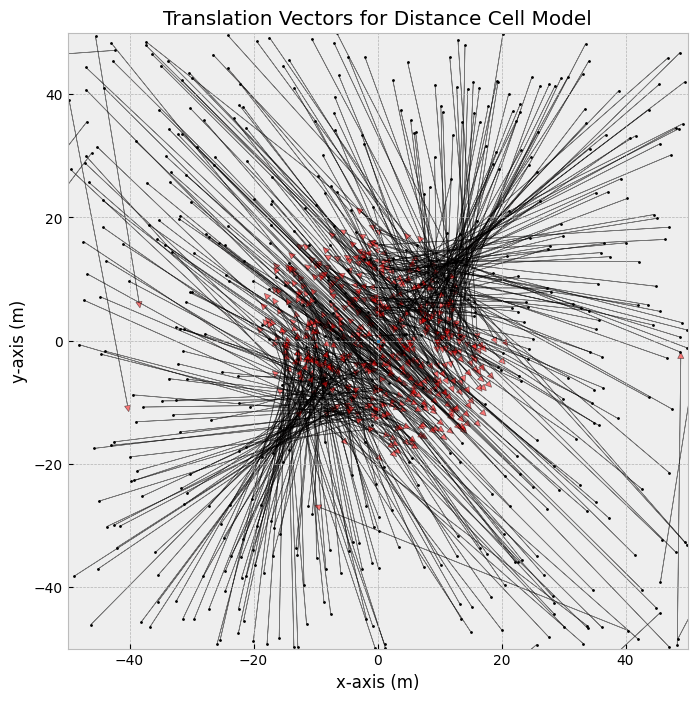

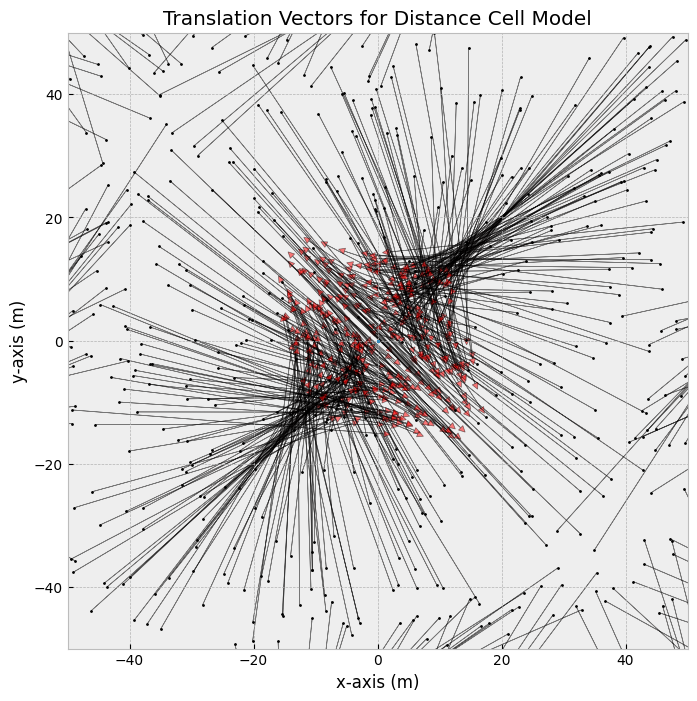

In [ ]:
trans_vec_results = {}
for model_name in ['dcm', 'vcm', 'nm']:
    a_s, b_s, pred_trans_vecs = translation_vec_simulation(model_name, 
                                                                  N=500, 
                                                                  arena_width = 50, 
                                                                  gc_distortion=GC_Distortion(distortion='shear', a=0.3, b=0.3))
    trans_vec_results[model_name] = (a_s, b_s, pred_trans_vecs)
plot_trans_vec_results(trans_vec_results)

### COMBINATORIAL (Bush et al., 2015)

In [ ]:
nm = NestedModel()
print(nm.forward(a=[250, 250], b=[258, 258]))
print(nm.forward(a=[-19, 1], b=[0, 0]))
print(nm.scales)


(-34.236222440563054, -54.79538506659507)
(18.70964991546043, -0.9138710114200769)
[100.          66.66666667  44.44444444  29.62962963  19.75308642
  13.16872428   8.77914952   5.85276635   3.90184423   2.60122949]


In [ ]:
nm = NestedModel()
print(nm.forward(a=[250, 250], b=[258, 258]))
print(nm.forward(a=[-19, 1], b=[0, 0]))
print(nm.scales)


(-33.99893737452001, -65.14446864694553)
(19.135270365284207, -1.0637288282421462)
[100.          66.66666667  44.44444444  29.62962963  19.75308642
  13.16872428   8.77914952   5.85276635   3.90184423   2.60122949]


In [ ]:

    def old_code(self, curr_pos, targ_pos, dim, curr_pos_dim, targ_pos_dim, multsyn_pos, multsyn_neg):
        for i, s_i in enumerate(self.scales):

            # Compute mean firing rates for each of the m GCs at start and goal, on each axis
            # Using index k directly as phase proxy (equivalent to Eq S6)
            start_rates = np.array([self._gc_rate(curr_pos_dim, s_i, p) * self.poiss_time_w for p in self.phases])
            goal_rates = np.array([self._gc_rate(targ_pos_dim, s_i, p) * self.poiss_time_w for p in self.phases])

            # Sample Poisson spikes
            start_spikes = np.random.poisson(start_rates)  # shape (m,)
            goal_spikes  = np.random.poisson(goal_rates)
    
            # Compute multiplicative synapse output via Grid_Vec_w
            # einsum: outer product (m, m) contracted with Grid_Vec_w (m, m, m) -> (m,)
            multsyn_pos[:, i] = np.einsum('ij,ijv->v', np.outer(start_spikes, goal_spikes), self.W_phasediff)
            multsyn_neg[:, i] = np.einsum('ij,ijv->v', np.outer(goal_spikes, start_spikes), self.W_phasediff)

        return multsyn_pos, multsyn_neg